In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
reg = DecisionTreeRegressor(random_state=42)
reg.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [31]:
preds = reg.predict(X_test)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"MAE : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R2 : {r2:.3f}")

MAE : 0.455
RMSE : 0.704
R2 : 0.622


In [32]:
df_metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [mae, rmse, r2]
})
df_metrics

,Metric,Value
0,MAE,0.454679
1,RMSE,0.703729
2,R2,0.622076


In [33]:
# Partie 2.2 – Validation croisée
reg_cv = DecisionTreeRegressor(max_depth=5, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    reg_cv,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=kf
)

print("Scores RMSE (négatifs) :", scores)
print("RMSE moyen :", -scores.mean())
print("Écart-type :", scores.std())

Scores RMSE (négatifs) : [-0.73676068 -0.72366202 -0.72052253 -0.72771551 -0.70514645]
RMSE moyen : 0.7227614362911459
Écart-type : 0.010359854323167076


In [ ]:
# Partie 2.3 – Comparaison de modèles
def evaluate_model(model, X, y):
    scores = cross_val_score(
        model,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=5
    )
    return -scores.mean()

models = {
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

results = []
for name, model in models.items():
    rmse = evaluate_model(model, X_train, y_train)
    results.append({"Model": name, "RMSE_CV": rmse})

results_df = pd.DataFrame(results)
results_df


In [25]:
best_model_name = results_df.sort_values("RMSE_CV").iloc[0]["Model"]

if best_model_name == "DecisionTree":
    best_model = DecisionTreeRegressor(random_state=42)
elif best_model_name == "RandomForest":
    best_model = RandomForestRegressor(random_state=42)
else:
    best_model = GradientBoostingRegressor(random_state=42)

# Réentraîner sur le train complet
best_model.fit(X_train, y_train)

# Prédictions sur test set
preds_test = best_model.predict(X_test)

# RMSE compatible toutes versions de scikit-learn
rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))

print(f"Meilleur modèle : {best_model_name}")
print(f"RMSE sur test set : {rmse_test:.3f}")


Meilleur modèle : RandomForest
RMSE sur test set : 0.505


   max_depth   rmse_cv
0          2  0.859221
1          3  0.795664
2          4  0.755470
3          5  0.712606
4          6  0.676735
5          7  0.652650
6          8  0.636682
7          9  0.632814
8         10  0.642836


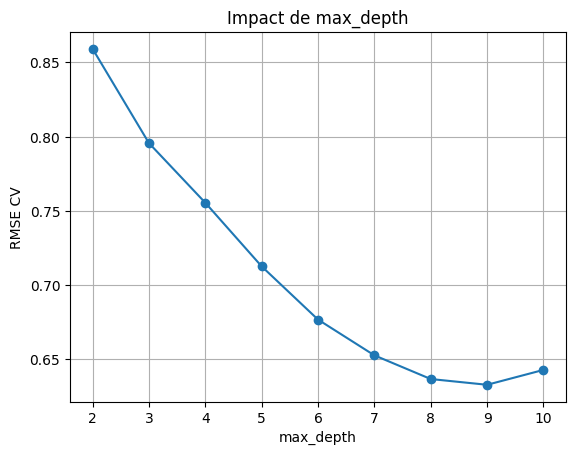

In [26]:
# Partie 3.1 – max_depth
results_depth = []

for depth in range(2, 11):
    reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    rmse_cv = -cross_val_score(
        reg,
        X_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=5
    ).mean()
    results_depth.append({"max_depth": depth, "rmse_cv": rmse_cv})

df_depth = pd.DataFrame(results_depth)
print(df_depth)

plt.plot(df_depth["max_depth"], df_depth["rmse_cv"], marker="o")
plt.xlabel("max_depth")
plt.ylabel("RMSE CV")
plt.title("Impact de max_depth")
plt.grid(True)
plt.show()


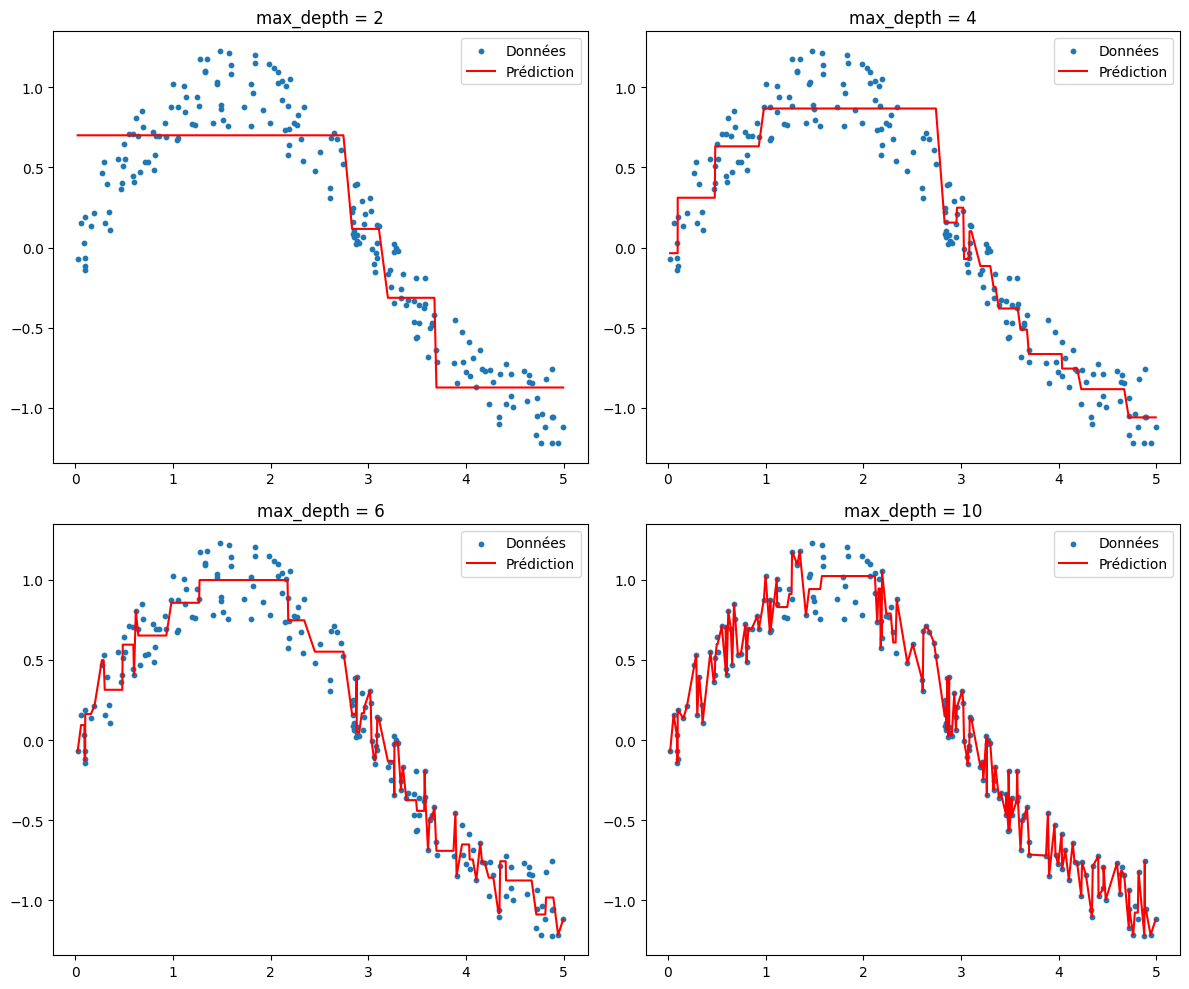

In [27]:
# Partie 3.2 – dataset synthétique et visualisation
rng = np.random.RandomState(0)
X_syn = np.sort(5 * rng.rand(200, 1), axis=0)
y_syn = np.sin(X_syn).ravel()
y_syn += 0.5 * (rng.rand(200) - 0.5)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, depth in zip(axes.ravel(), [2, 4, 6, 10]):
    reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    reg.fit(X_syn, y_syn)
    ax.scatter(X_syn, y_syn, s=10, label="Données")
    ax.plot(X_syn, reg.predict(X_syn), color="red", label="Prédiction")
    ax.set_title(f"max_depth = {depth}")
    ax.legend()

plt.tight_layout()
plt.show()
